<div style="text-align: center; margin-bottom: 2rem; font-family: sans-serif;">
  <hr style="border: none; border-top: 1px solid #ccc; margin-bottom: 1rem;">
  <p style="margin: 4px 0; font-size: 1.2em; font-weight: bold;">EN3160 Assignment 1: Intensity Transformations and Neighborhood Filtering</p>
  <p style="margin: 4px 0;">230033J Amarasinghe A.A.D.K.</p>
  <p style="margin: 4px 0;">13 September 2026</p>
  <p style="margin: 4px 0;"><a href="https://github.com/your-username/repository">https://github.com/Dulith-Kavinda/Intensity_Transformations_and_Neighborhood_Filtering</a></p>
  <hr style="border: none; border-top: 1px solid #ccc; margin-top: 1rem;">
</div>

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#### Load Images

In [2]:
def load_image(path, condition):
    match condition:
        case True:
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
        case False:
            img = cv.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")
    return img

#### Task 01

In [30]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs, ys = breakpoints[:, 0], breakpoints[:, 1]
    lut = np.interp(np.arange(256), xs, ys).astype(np.uint8)
    out = cv.LUT(im, lut)
    return out, lut

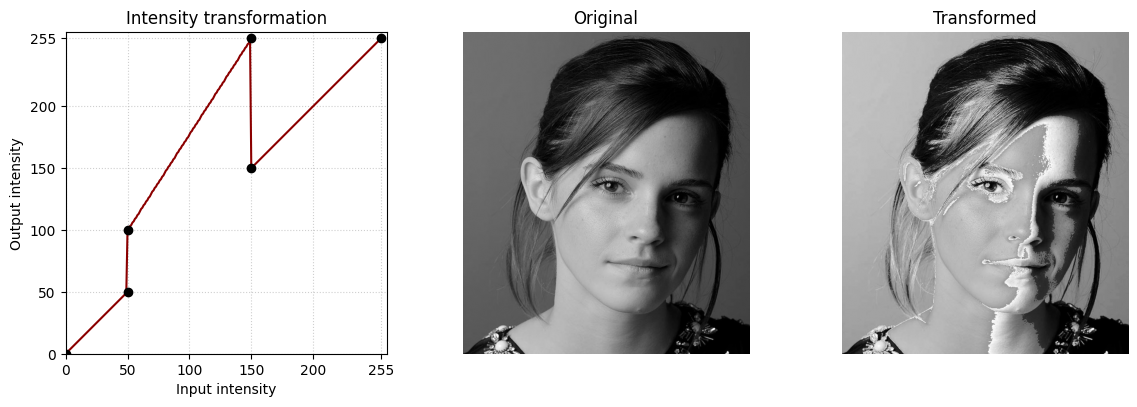

In [42]:
def task_01():
    img = load_image("images/q1.jpeg", True)

    breakpoints = np.array([
        [0,   0],
        [50,  50],
        [50, 100],
        [150, 255],
        [150, 150],
        [255, 255],
    ])

    out, lut = intensity_transform(img, breakpoints)
    ticks = [0, 50, 100, 150, 200, 255] 
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].plot(np.arange(256), lut, color="darkred")
    ax[0].plot(breakpoints[:, 0], breakpoints[:, 1], "ko")
    ax[0].set_xlim(0, 260)
    ax[0].set_ylim(0, 260)
    ax[0].set_xticks(ticks)
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel("Input intensity")
    ax[0].set_ylabel("Output intensity")
    ax[0].set_title("Intensity transformation")
    ax[0].set_aspect("equal")
    ax[0].grid(True, linestyle=":", alpha=0.6)
    ax[1].imshow(img, cmap="gray")
    ax[1].set_title("Original")
    ax[1].axis("off")
    ax[2].imshow(out, cmap="gray")
    ax[2].set_title("Transformed")
    ax[2].axis("off")
    plt.tight_layout()
    plt.show()


task_01()

#### Task 02

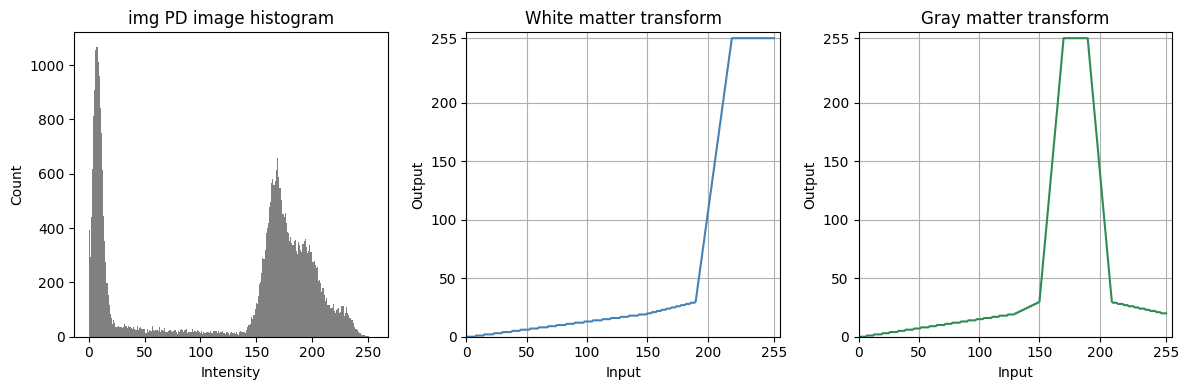

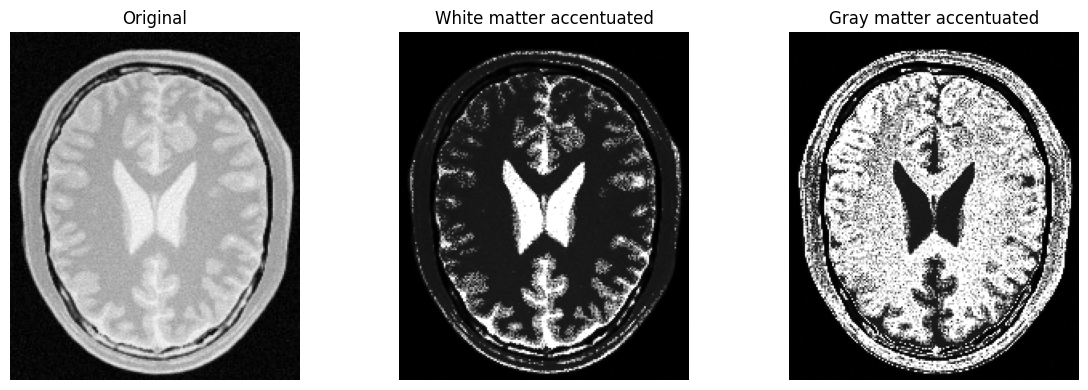

In [ ]:
def task_02():
    img = load_image("images/q2.jpeg", True)

    # White matter: accentuate 190-250 suppress everything else
    breakpoints_white = np.array([
        [0,   0],
        [150, 20],
        [190, 30],
        [220, 255],
        [255, 255],
    ])
    
    # Gray matter: accentuate 140-190, suppress everything else
    breakpoints_gray = np.array([
        [0,   0],
        [130, 20],
        [150, 30],
        [170, 255],
        [190, 255],
        [210, 30],
        [255, 20],
    ])

    white_img, white_lut = intensity_transform(img, breakpoints_white)
    gray_img, gray_lut = intensity_transform(img, breakpoints_gray)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    ax[0].set_title("img PD image histogram")
    ax[0].set_xlabel("Intensity")
    ax[0].set_ylabel("Count")

    ticks = [0, 50, 100, 150, 200, 255] 

    ax[1].plot(white_lut, color="steelblue")
    ax[1].set_title("White matter transform")
    ax[2].plot(gray_lut, color="seagreen")
    ax[2].set_title("Gray matter transform")

    for a in ax[1:]:
        a.set_xticks(ticks)
        a.set_yticks(ticks)
        a.set_xlim(0, 260)
        a.set_ylim(0, 260)
        a.set_xlabel("Input")
        a.set_ylabel("Output")
        a.grid(True)
        
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, im, title in zip(
        axes,
        [img, white_img, gray_img],
        ["Original", "White matter accentuated", "Gray matter accentuated"],
    ):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

task_02()

By looking this histogramme we can say 0 to nearly 25 are not brain tissues and also 25 to 148 also near to zero so brain intensities nearly start from 150 and when we show white matters we can show high intensity pixels clearly(190-255) and suppress others and also in gray matter we have to show low intensities pixels represent brain with band pass filter(140-190).

#### Task 03


This is darken image so we have to use gamma < 1 to brighten this.

Gamma value used: 0.6


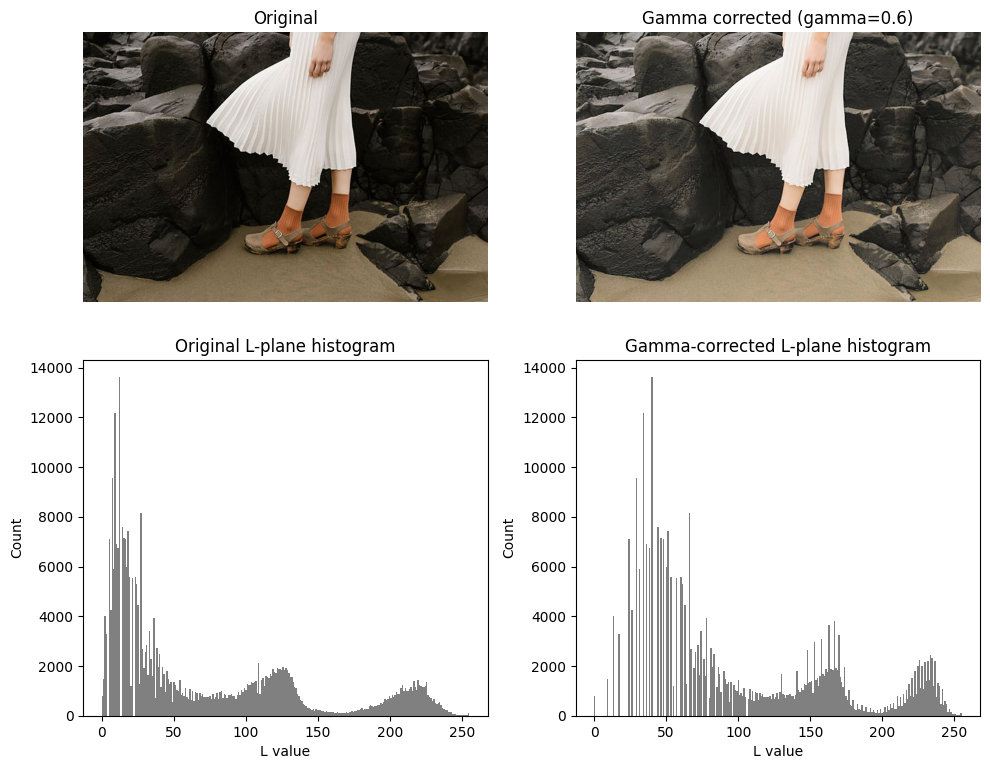

In [ ]:
def task_03():
    img= load_image("images/q3.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    L, a, b = cv.split(lab)

    gamma = 0.6
    L_norm = L.astype(np.float64) / 255.0
    L_gamma = np.power(L_norm, gamma) * 255.0
    L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

    lab_corrected = cv.merge([L_gamma, a, b])
    img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
    img_corrected_rgb = cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB)

    print(f"Gamma value used: {gamma}")

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0,0].imshow(img_rgb)
    axes[0,0].set_title("Original")
    axes[0,0].axis("off")
    axes[0,1].imshow(img_corrected_rgb)
    axes[0,1].set_title(f"Gamma corrected (gamma={gamma})")
    axes[0,1].axis("off")
    axes[1,0].hist(L.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,0].set_title("Original L-plane histogram")
    axes[1,1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,1].set_title("Gamma-corrected L-plane histogram")
    for ax in axes[1,:]:
        ax.set_xlabel("L value")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

task_03()

#### Task 04

a = 0.5, sigma = 70


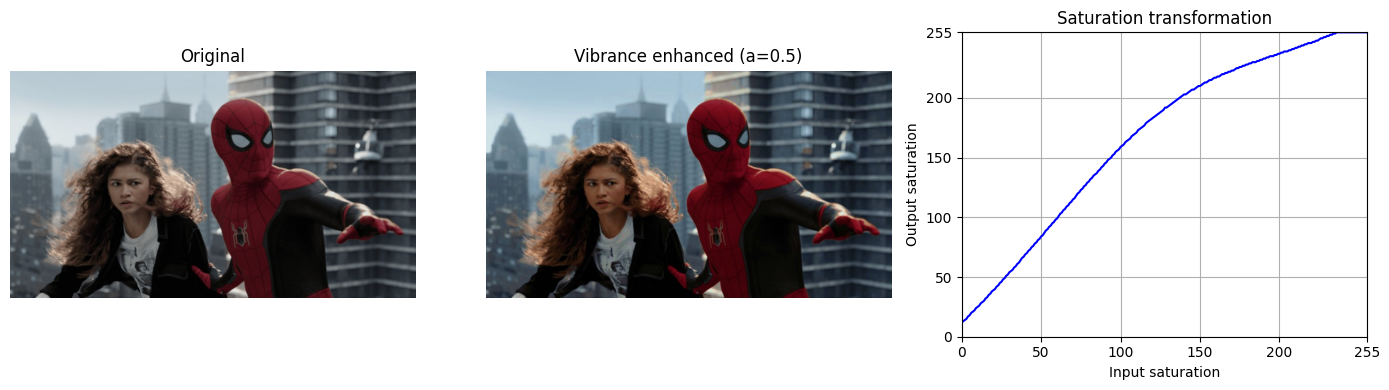

In [ ]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boosted = x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255).astype(np.uint8)

def task_04():
    img = load_image("images/q4.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    a = 0.5  # [0, 1]
    sigma = 70
    s_boosted = vibrance_transform(s, a, sigma)
    hsv_boosted = cv.merge([h, s_boosted, v])
    img_vibrant = cv.cvtColor(hsv_boosted, cv.COLOR_HSV2BGR)
    img_vibrant_rgb = cv.cvtColor(img_vibrant, cv.COLOR_BGR2RGB)
    print(f"a = {a}, sigma = {sigma}")

    xs = np.arange(256)
    ys = vibrance_transform(xs, a, sigma)
    
    ticks = [0, 50, 100, 150, 200, 255] 
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    plt.xticks(ticks)
    plt.yticks(ticks)
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(img_vibrant_rgb)
    axes[1].set_title(f"Vibrance enhanced (a={a})")
    axes[1].axis("off")
    axes[2].plot(xs, ys, color="blue")
    axes[2].set_title("Saturation transformation")
    axes[2].set_xlabel("Input saturation")
    axes[2].set_ylabel("Output saturation")
    axes[2].set_xlim(0, 255)
    axes[2].set_ylim(0, 255)
    axes[2].grid(True)
    plt.tight_layout()
    plt.show()

task_04()

#### Task 05

In [ ]:
def histogram_equalize(im):
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
    cdf = np.cumsum(hist).astype(np.float64)
    total_pixels = im.size
    lut = np.round(((cdf / total_pixels) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv.LUT(im, lut)


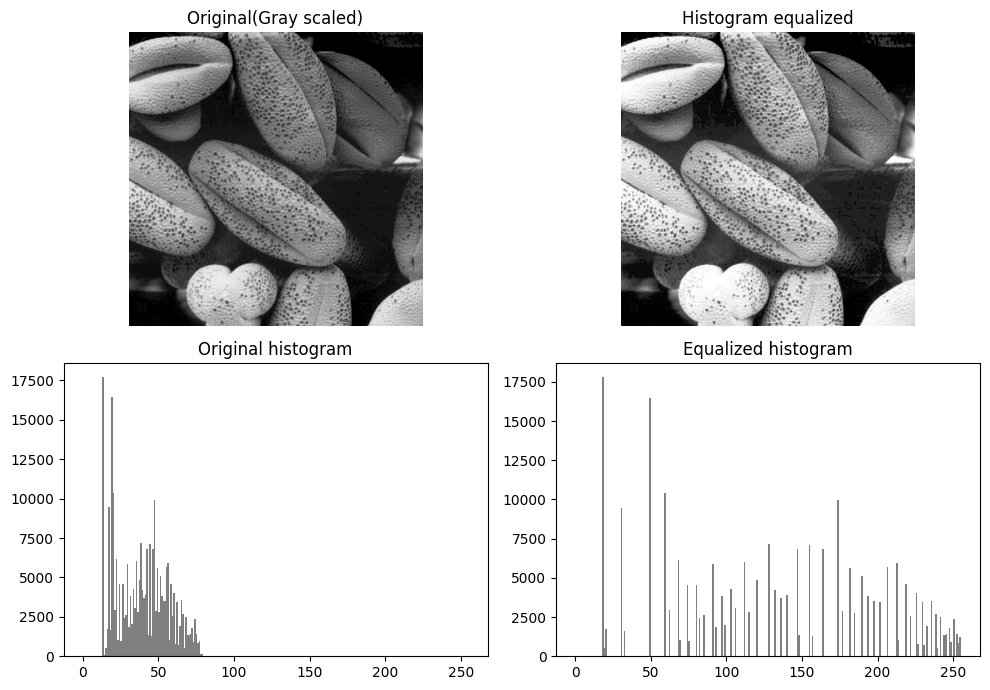

In [81]:

def task_05():
    img = load_image("images/q5.tif", True)

    img_eq = histogram_equalize(img)

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes[0,0].imshow(img, cmap="gray")
    axes[0,0].set_title("Original(Gray scaled)")
    axes[0,0].axis("off")
    axes[0,1].imshow(img_eq, cmap="gray")
    axes[0,1].set_title("Histogram equalized")
    axes[0,1].axis("off")
    axes[1,0].hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,0].set_title("Original histogram")
    axes[1,1].hist(img_eq.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,1].set_title("Equalized histogram")
    plt.tight_layout()
    plt.show()

task_05()

#### Task 06

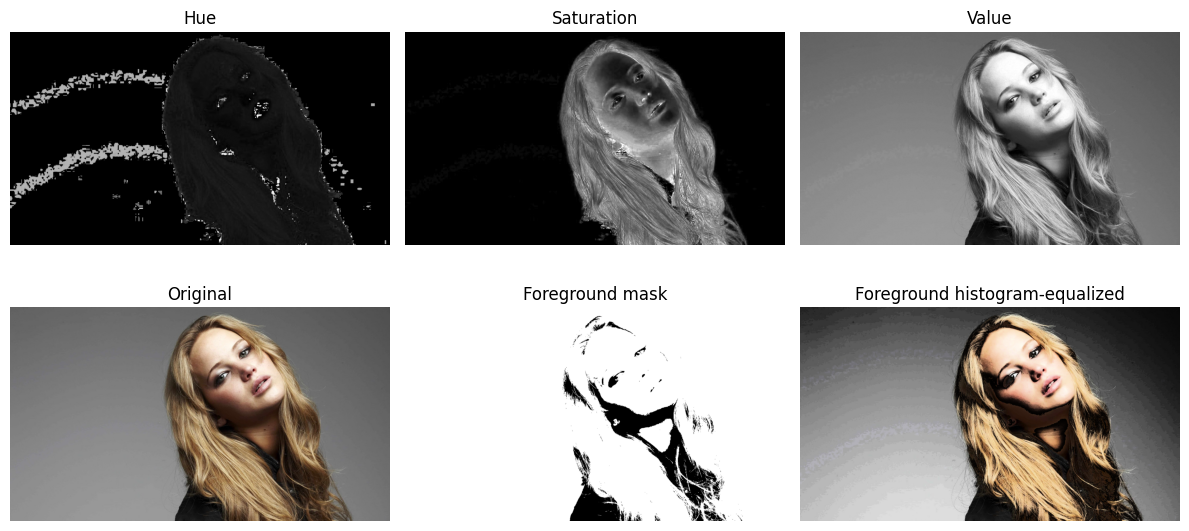

In [84]:
def task_06():
    img_bgr = load_image("images/q6.jpeg", False)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    for ax, plane, title in zip(axes[0,:], [h, s, v], ["Hue", "Saturation", "Value"]):
        ax.imshow(plane, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

    _, mask = cv.threshold(v, 60, 255, cv.THRESH_BINARY)  #select threshold imaga as v channel because thre we can clearly separate image background and foreground.
    mask = mask.astype(np.uint8)

    foreground = cv.bitwise_and(v, v, mask=mask)
    hist_fg = cv.calcHist([v], [0], mask, [256], [0, 256]).flatten()
    cdf_fg = np.cumsum(hist_fg)

    num_pixels = cdf_fg[-1]
    lut_fg = np.round((cdf_fg / num_pixels) * 255.0)
    lut_fg = np.clip(lut_fg, 0, 255).astype(np.uint8)
    fg_equalized = cv.LUT(v, lut_fg)
    fg_equalized = cv.bitwise_and(fg_equalized, fg_equalized, mask=mask)

    inv_mask = cv.bitwise_not(mask)
    background = cv.bitwise_and(v, v, mask=inv_mask)
    v_result = cv.add(background, fg_equalized)
    hsv_result = cv.merge([h, s, v_result])
    img_result = cv.cvtColor(hsv_result, cv.COLOR_HSV2BGR)
    img_result_rgb = cv.cvtColor(img_result, cv.COLOR_BGR2RGB)

    for ax, im, title in zip(
        axes[1,:],
        [img_rgb, mask, img_result_rgb],
        ["Original", "Foreground mask", "Foreground histogram-equalized"],
    ):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

task_06()

#### Task 07

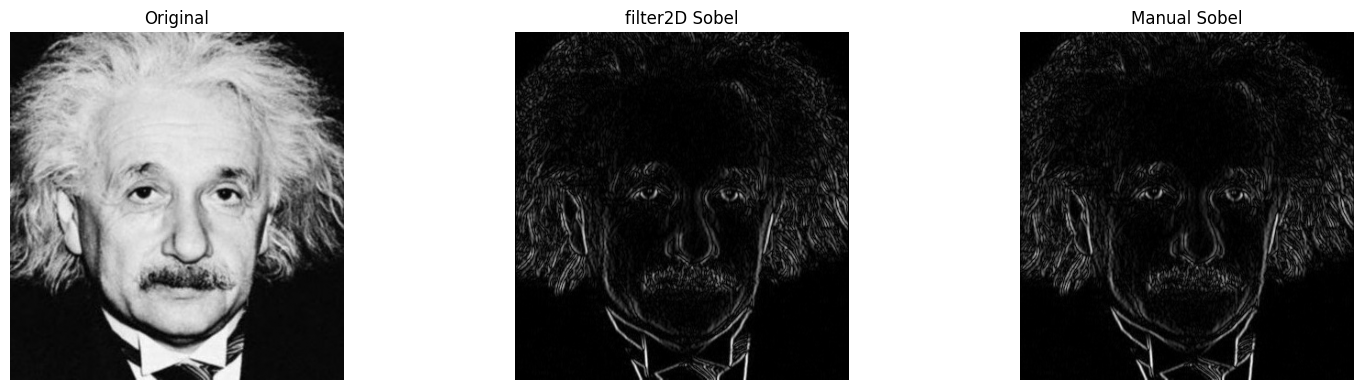

In [87]:
def sobel_manual(im, kernel):
    im = im.astype(np.float64)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    out = np.zeros_like(im)
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i + im.shape[0], j:j + im.shape[1]]
    return out


def to_display(im):
    im = np.abs(im)
    return (255 * im / (im.max() + 1e-8)).astype(np.uint8)


def task_07():
    img_grayed = load_image("images/q7.jpeg", True)

    sobel_x_kernel = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]], dtype=np.float64)
    sobel_x_cv = cv.filter2D(img_grayed.astype(np.float64), -1, sobel_x_kernel)

    sobel_x_manual = sobel_manual(img_grayed, sobel_x_kernel)

    col = np.array([[1], [2], [1]], dtype=np.float64)
    row = np.array([[1, 0, -1]], dtype=np.float64)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    imgs = [img_grayed, to_display(sobel_x_cv), to_display(sobel_x_manual)]
    titles = ["Original", "filter2D Sobel", "Manual Sobel"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


task_07()

#### Task 08

im01small.png: nearest neighbor SSD = 136.269, bilinear SSD = 115.126


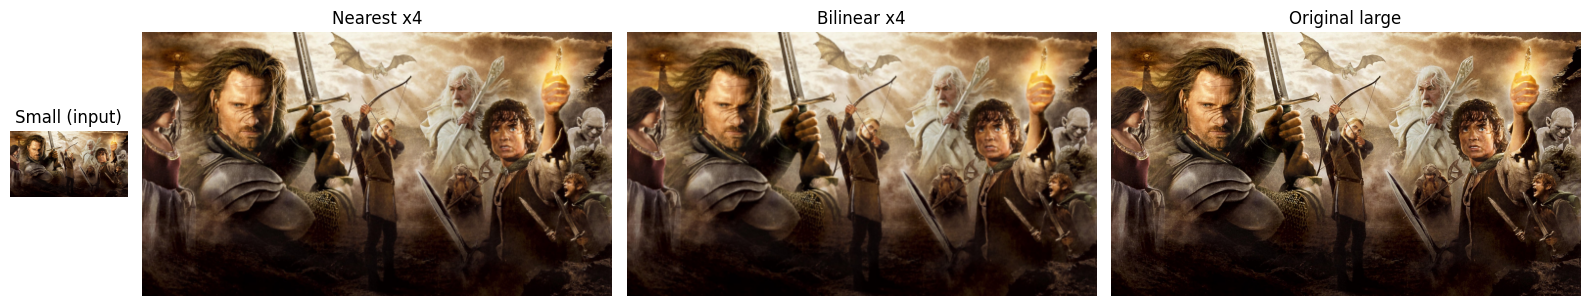

im02small.png: nearest neighbor SSD = 26.446, bilinear SSD = 18.397


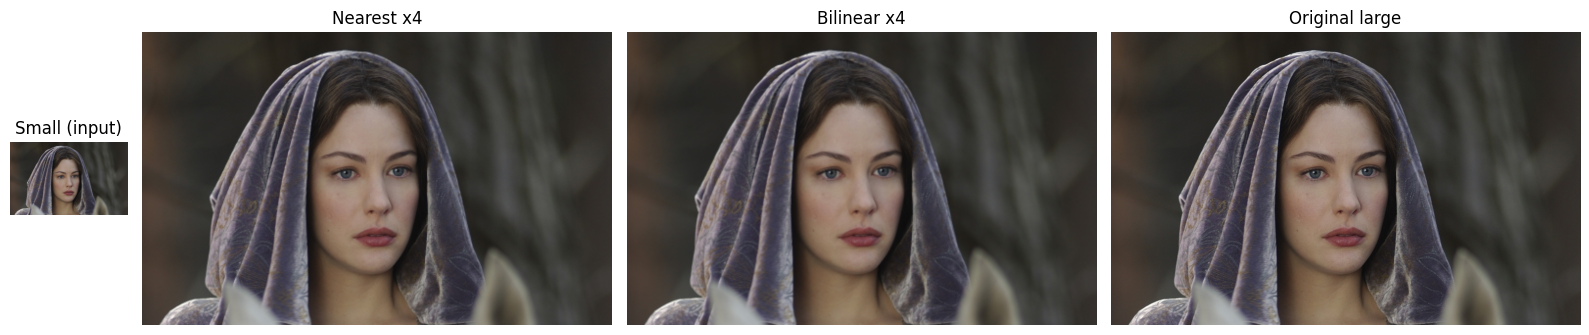

im03small.png: nearest neighbor SSD = 67.582, bilinear SSD = 51.320


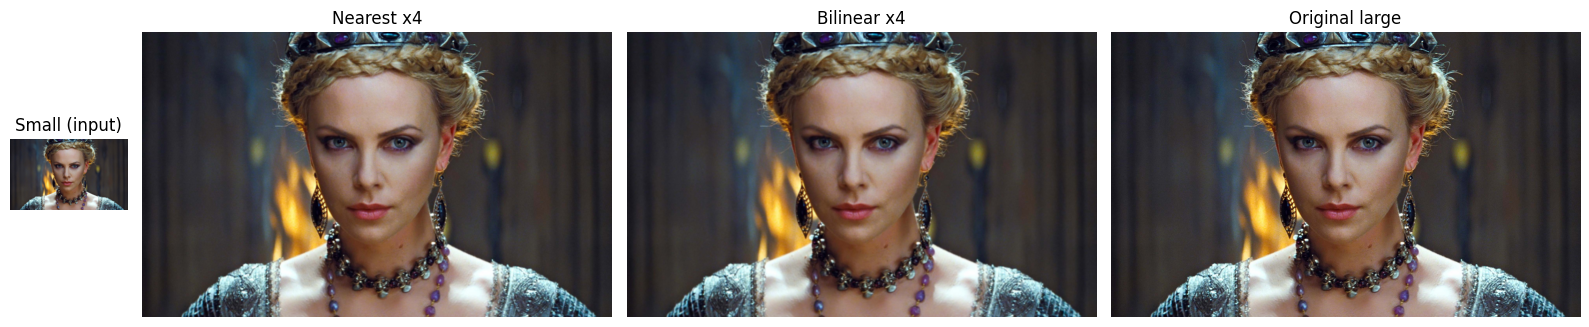

im04small.jpg: nearest neighbor SSD = 228.622, bilinear SSD = 196.766


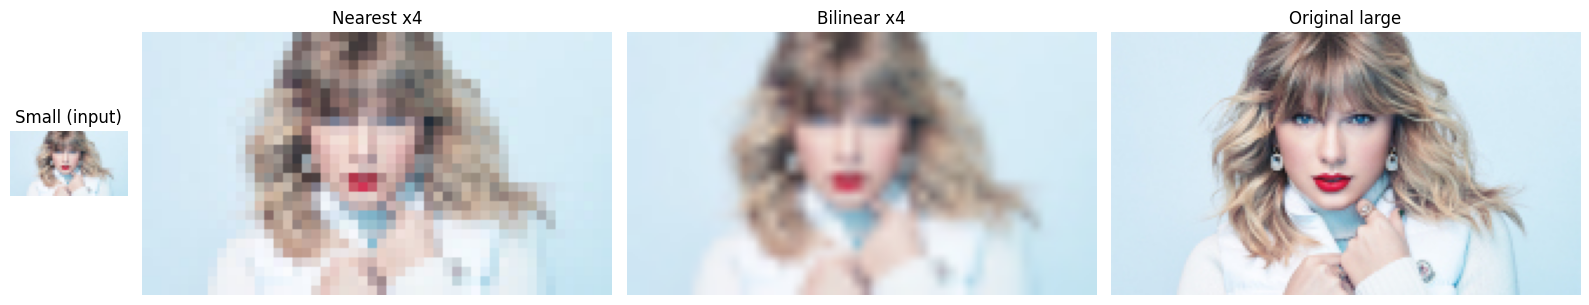

In [93]:
from matplotlib.gridspec import GridSpec

def zoom_image(im, s, method):
    assert 0 < s <= 10, "s must be in (0, 10]"
    im_f = im.astype(np.float64)
    H, W = im.shape[:2]
    new_H, new_W = max(1, round(H * s)), max(1, round(W * s))

    ys = (np.arange(new_H) + 0.5) / s - 0.5
    xs = (np.arange(new_W) + 0.5) / s - 0.5

    if method == "nearest":
        y_idx = np.clip(np.round(ys), 0, H - 1).astype(int)
        x_idx = np.clip(np.round(xs), 0, W - 1).astype(int)
        out = im_f[np.ix_(y_idx, x_idx)]

    elif method == "bilinear":
        y0 = np.clip(np.floor(ys), 0, H - 1).astype(int)
        x0 = np.clip(np.floor(xs), 0, W - 1).astype(int)
        y1 = np.clip(y0 + 1, 0, H - 1)
        x1 = np.clip(x0 + 1, 0, W - 1)

        wy = np.clip(ys - y0, 0, 1)
        wx = np.clip(xs - x0, 0, 1)

        Ia = im_f[np.ix_(y0, x0)]
        Ib = im_f[np.ix_(y0, x1)]
        Ic = im_f[np.ix_(y1, x0)]
        Id = im_f[np.ix_(y1, x1)]

        wy_ = wy[:, None]
        wx_ = wx[None, :]
        if im_f.ndim == 3:
            wy_ = wy_[..., None]
            wx_ = wx_[..., None]
        top = Ia * (1 - wx_) + Ib * wx_
        bottom = Ic * (1 - wx_) + Id * wx_
        out = top * (1 - wy_) + bottom * wy_

    return np.clip(out, 0, 255).astype(im.dtype)


def normalized_ssd(im1, im2):
    a = im1.astype(np.float64)
    b = im2.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size


def task_08():
    pairs = [
        ("images/im01small.png", "images/im01.png"),
        ("images/im02small.png", "images/im02.png"),
        ("images/im03small.png", "images/im03.png"),
        ("images/im04small.jpg", "images/im04.jpg"),
    ]

    for small_path, large_path in pairs:
        small_bgr = cv.imread(small_path)
        large_bgr = cv.imread(large_path)
        if small_bgr is None or large_bgr is None:
            print(f"missing pair: {small_path}, {large_path}")
            break

        small = cv.cvtColor(small_bgr, cv.COLOR_BGR2RGB)
        large = cv.cvtColor(large_bgr, cv.COLOR_BGR2RGB)

        up_nn = zoom_image(small, 4, method="nearest")
        up_bl = zoom_image(small, 4, method="bilinear")

        h = min(up_nn.shape[0], large.shape[0])
        w = min(up_nn.shape[1], large.shape[1])

        ssd_nn = normalized_ssd(up_nn[:h, :w], large[:h, :w])
        ssd_bl = normalized_ssd(up_bl[:h, :w], large[:h, :w])

        print(f"{small_path[7:]}: nearest neighbor SSD = {ssd_nn:.3f}, bilinear SSD = {ssd_bl:.3f}")

        imgs = [small, up_nn[:h, :w], up_bl[:h, :w], large[:h, :w]]
        titles = ["Small (input)", "Nearest x4", "Bilinear x4", "Original large"]

        widths = [im.shape[1] for im in imgs]
        fig = plt.figure(figsize=(16, 4))
        gs = GridSpec(1, 4, width_ratios=widths, figure=fig)
        axes = [fig.add_subplot(gs[i]) for i in range(4)]

        for ax, im, title in zip(axes, imgs, titles):
            ax.imshow(im)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

task_08()

### Task 09

In [ ]:
def task_09():
    flower_bgr = load_image("images/q9.jpeg", False)
    flower_rgb = cv.cvtColor(flower_bgr, cv.COLOR_BGR2RGB)

    # (a) GrabCut segmentation
    mask = np.zeros(flower_bgr.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    # Initial rectangle should tightly bound the flower; adjust to your image
    h, w = flower_bgr.shape[:2]
    rect = (int(0.1 * w), int(0.05 * h), int(0.85 * w), int(0.9 * h))

    cv.grabCut(flower_bgr, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

    final_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 255, 0).astype(np.uint8)

    foreground = cv.bitwise_and(flower_bgr, flower_bgr, mask=final_mask)
    background = cv.bitwise_and(flower_bgr, flower_bgr, mask=cv.bitwise_not(final_mask))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    imgs = [flower_rgb, final_mask, cv.cvtColor(foreground, cv.COLOR_BGR2RGB), cv.cvtColor(background, cv.COLOR_BGR2RGB)]
    titles = ["Original", "Segmentation mask", "Foreground", "Background"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task9_segmentation.png", dpi=150)
    plt.show()

    # (b) Substantially blur the background and recombine with the sharp foreground
    blurred_bg = cv.GaussianBlur(flower_bgr, (0, 0), sigmaX=15)

    mask_float = (final_mask.astype(np.float64) / 255.0)[..., None]
    enhanced = (flower_bgr.astype(np.float64) * mask_float +
                blurred_bg.astype(np.float64) * (1 - mask_float)).astype(np.uint8)
    enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(flower_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(enhanced_rgb)
    axes[1].set_title("Background blurred")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task9_background_blur.png", dpi=150)
    plt.show()


    cv.imwrite("task9_mask.png", final_mask)
    cv.imwrite("task9_output.png", enhanced)

task_09()

### Task 10

In [ ]:
def bilateral_filter_manual(im, sigma_s, sigma_r, radius=None):
    if radius is None:
        radius = int(2 * sigma_s)

    im_f = im.astype(np.float64)
    H, W, C = im_f.shape
    padded = cv.copyMakeBorder(im_f, radius, radius, radius, radius, cv.BORDER_REFLECT)

    # Precompute the spatial Gaussian weights (same for every pixel)
    ax = np.arange(-radius, radius + 1)
    gx, gy = np.meshgrid(ax, ax)
    spatial_weights = np.exp(-(gx ** 2 + gy ** 2) / (2 * sigma_s ** 2))

    out = np.zeros_like(im_f)

    for i in range(H):
        for j in range(W):
            patch = padded[i:i + 2 * radius + 1, j:j + 2 * radius + 1, :]
            center = padded[i + radius, j + radius, :]
            diff = patch - center
            range_weights = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_r ** 2))
            weights = spatial_weights * range_weights
            weights_sum = weights.sum()
            out[i, j, :] = (patch * weights[..., None]).sum(axis=(0, 1)) / weights_sum

    return np.clip(out, 0, 255).astype(np.uint8)


def psnr(im1, im2):
    mse = np.mean((im1.astype(np.float64) - im2.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))


def task_10():
    img_bgr = load_image("images/q10.jpeg", False)
    lake_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    sigma_s, sigma_r = 15, 75  # spatial / range sigmas, tune for visible edge-preserving smoothing

    # (a) OpenCV bilateral filter vs. Gaussian blur with a comparable kernel
    bilateral_cv = cv.bilateralFilter(img_bgr, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
    gaussian_cv = cv.GaussianBlur(img_bgr, (9, 9), sigmaX=sigma_s)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    imgs = [lake_rgb, cv.cvtColor(gaussian_cv, cv.COLOR_BGR2RGB), cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB)]
    titles = ["Original", "Gaussian blur", "cv.bilateralFilter"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task10_opencv_bilateral.png", dpi=150)
    plt.show()

    # (b) Own implementation, compared on a small crop for reasonable runtime
    crop = img_bgr[100:200, 150:250]
    crop_bilateral_manual = bilateral_filter_manual(crop, sigma_s=5, sigma_r=50, radius=5)
    crop_bilateral_cv = cv.bilateralFilter(crop, d=11, sigmaColor=50, sigmaSpace=5)
    crop_gaussian = cv.GaussianBlur(crop, (11, 11), sigmaX=5)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    imgs = [
        cv.cvtColor(crop, cv.COLOR_BGR2RGB),
        cv.cvtColor(crop_gaussian, cv.COLOR_BGR2RGB),
        cv.cvtColor(crop_bilateral_cv, cv.COLOR_BGR2RGB),
        cv.cvtColor(crop_bilateral_manual, cv.COLOR_BGR2RGB),
    ]
    titles = ["Crop (original)", "Gaussian", "cv.bilateralFilter", "Manual bilateral"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task10_manual_vs_cv.png", dpi=150)
    plt.show()

    print(f"PSNR (manual vs cv.bilateralFilter): {psnr(crop_bilateral_manual, crop_bilateral_cv):.2f} dB")
    ssd = np.sum((crop_bilateral_manual.astype(np.float64) - crop_bilateral_cv.astype(np.float64)) ** 2)
    print(f"SSD  (manual vs cv.bilateralFilter): {ssd:.2f}")

    cv.imwrite("task10_bilateral_cv.png", bilateral_cv)

task_10()